# 02 — 피처 생성 · 전처리 선택 · 모델 비교

**전제**: 01번이 먼저 실행되어 `../outputs/01_기준선/L_loss.pkl` 이 있어야 한다.
(01번에서 품질 필터가 이미 적용된 Loss 시계열이다.)

## 원칙
1. **누수 차단** — 모든 피처는 예측 시점 *이전* 정보만. lag/rolling 전부 `shift()` 선적용
2. **시간순 분할** — 2024년까지 학습 / 2025년 평가
3. **기준선 대비 평가** — 절대 R² 가 아니라 개선률로 판단
4. **목적 구간 전용** — 평일 출퇴근 6시간만
5. **전처리·모델은 비교 후 근거로 선택**

## 구성
| 절 | 내용 |
|---|---|
| 1 | 구성 성분 재계산 |
| 2 | 피처 생성 + 누수 자가점검 |
| 3 | 전처리 8종 비교 |
| 4 | 모델 14종 비교 |
| 5 | 최종 성능 + **부트스트랩 신뢰구간** |
| 6 | 변수 중요도 |
| 7 | [부록] 평가 범위가 R² 에 미치는 영향 |
| 8 | 시각화 및 요약 |

**핵심 주의**: `Loss(t)=진출(t)−진입(t)` 이므로 동시각 진출·진입을 피처로 넣으면
정답을 알려주는 셈(R²=1.0)이다. 반드시 shift 후에만 쓴다.

## 0. 설정

In [1]:
LOSS_PKL    = "../outputs/01_기준선/L_loss.pkl"
RAW_MIGEUM  = "../data/raw/미금역사거리.csv"
RAW_DONGMAK = "../data/raw/동막교사거리.csv"
REF_AVENUE  = "../data/raw/접근로정보.csv"
OUT_DIR     = "../outputs/02_모델링"

TEST_START    = "2025-01-01"
LAGS  = [1, 2, 3, 24, 168]
ROLLS = [24, 168]
ROLL_MIN_FRAC = 0.5    # 품질필터로 생긴 구멍 대응: 창의 절반만 있어도 이동평균 계산
N_BOOT = 1000
SEED   = 42

In [2]:
import os, sys, warnings, builtins
import numpy as np, pandas as pd
import matplotlib, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
os.makedirs(OUT_DIR, exist_ok=True)
for f in ["Malgun Gothic","NanumGothic","AppleGothic"]:
    try: matplotlib.rc("font", family=f); break
    except Exception: pass
matplotlib.rcParams["axes.unicode_minus"]=False

_LOG=[]
def print(*args, sep=" ", end="\n", **kw):
    _LOG.append(sep.join(str(a) for a in args)+end)
    builtins.print(*args, sep=sep, end=end, **kw)
def save_log(path):
    with open(path,"w",encoding="utf-8") as fh: fh.write("".join(_LOG))
    builtins.print(f"로그 저장: {path}  ({len(_LOG)}줄)")
def sec(t): print("\n"+"="*80+"\n"+t+"\n"+"="*80)

L=pd.read_pickle(LOSS_PKL); full=L.index
TR=(full<TEST_START); TE=(full>=TEST_START)
print(f"Loss 시계열: {len(L):,} 슬롯 ({full[0]:%Y-%m-%d} ~ {full[-1]:%Y-%m-%d})")
for col in ["NB","SB"]:
    print(f"  {col}: train {int((TR&L.commute&L[col].notna()).sum()):,} / "
          f"test {int((TE&L.commute&L[col].notna()).sum()):,}")

Loss 시계열: 16,005 슬롯 (2023-11-07 ~ 2025-09-04)
  NB: train 1,303 / test 767
  SB: train 1,114 / test 394


## 1. 구성 성분 재계산 (피처 원자재)

Loss 를 만든 진출/진입 원자재를 다시 계산한다. **오직 lag 형태로만** 사용한다.
01번과 동일한 품질 필터를 적용한다.

In [3]:
sec("1. 구성 성분 재계산")
def load(p):
    d=pd.read_csv(p,encoding="utf-8-sig")
    d.columns=[c.strip().strip('"') for c in d.columns]
    return d
df=pd.concat([load(RAW_MIGEUM),load(RAW_DONGMAK)],ignore_index=True)
df["dt"]=pd.to_datetime(df["CollectedDate"]).dt.floor("h")

ref=load(REF_AVENUE); ref=ref[ref.IntersectionSeq.isin([37,48])].set_index("AvenueSeq")
own_exit={}
for iid in [37,48]:
    sub=ref[ref.IntersectionSeq==iid]; allex=set()
    for _,r in sub.iterrows(): allex|={r.StraightLinkID,r.TurnLeftLinkID,r.TurnRightLinkID}
    allex={int(x) for x in allex if pd.notna(x)}
    for av,r in sub.iterrows():
        used={int(x) for x in [r.StraightLinkID,r.TurnLeftLinkID,r.TurnRightLinkID] if pd.notna(x)}
        own_exit[av]=list(allex-used)[0]
print("[Av144 오류 확인]")
for av in [142,143,144,145]:
    ok="OK" if own_exit[av]==ref.loc[av,"CoupleLinkID"] else "<<< 파일 오류 → 역산값 사용"
    print(f"  Av{av} 역산={own_exit[av]}  파일={int(ref.loc[av,'CoupleLinkID'])}  {ok}")

def exit_link(av,mv):
    r=ref.loc[av]
    return int({1:r.StraightLinkID,2:r.TurnLeftLinkID,3:r.TurnRightLinkID,4:own_exit[av]}[mv])
df["exit"]=[exit_link(a,m) for a,m in zip(df.AvenueSeq,df.MovementType)]
E=df.groupby(["AvenueSeq","dt"])["Volume"].sum().unstack(0)
xv=df.groupby(["IntersectionSeq","exit","dt"])["Volume"].sum()
X=pd.DataFrame({av: xv.loc[(ref.loc[av,"IntersectionSeq"],own_exit[av])] for av in ref.index})

comp=pd.DataFrame(index=full)
comp["NB_out"]=X[183].reindex(full).where(L.valid_NB)
comp["NB_in"] =E[144].reindex(full).where(L.valid_NB)
comp["SB_out"]=X[144].reindex(full).where(L.valid_SB)
comp["SB_in"] =E[183].reindex(full).where(L.valid_SB)
print("\n[구성 성분 요약 — 품질필터 적용 후]")
print(comp.describe().round(1).to_string())


1. 구성 성분 재계산
[Av144 오류 확인]
  Av142 역산=2060032900  파일=2060032900  OK
  Av143 역산=2060032700  파일=2060032700  OK
  Av144 역산=2060030900  파일=2060032400  <<< 파일 오류 → 역산값 사용
  Av145 역산=2060032400  파일=2060032400  OK

[구성 성분 요약 — 품질필터 적용 후]
        NB_out    NB_in  SB_out   SB_in
count  10179.0  10179.0  7456.0  7456.0
mean     961.7    966.2   814.3  1059.4
std      458.8    443.5   375.4   504.2
min       33.0     24.0    32.0    29.0
25%      640.5    621.0   515.0   634.0
50%     1037.0    997.0   880.0  1221.0
75%     1248.0   1310.0  1090.2  1444.0
max     2259.0   2163.0  1760.0  2000.0


## 2. 피처 생성 — 전부 shift 적용

| 피처 | 의미 |
|---|---|
| lag_1/2/3, lag_24, lag_168 | 과거 Loss |
| roll24 / roll168 | 이동평균 (**shift(1) 선적용**) |
| *_out_lag1, *_in_lag1 / _lag24 | 과거 진출·진입 교통량 |
| hour / dow / month | 달력 정보 |
| base_med | 학습기간의 (요일×시각) 중앙값 = '평소값' |

### `min_periods` 를 쓰는 이유
품질 필터로 제외된 시각은 NaN 이라, 168시간 창에 구멍이 하나만 있어도 `roll168` 이
계산되지 않아 학습 표본이 급감한다. 창의 **절반 이상** 값이 있으면 계산하도록 완화한다.
과거 값만 쓰므로 누수가 아니다.

In [4]:
sec("2. 피처 생성")
def make_base(col):
    med=L[TR].groupby([L.dow,L.hour])[col].median()
    return pd.Series([med.get((d,h),np.nan) for d,h in zip(L.dow,L.hour)],index=full)

def build(y,col,base=None):
    d=pd.DataFrame(index=full)
    for lag in LAGS: d[f"lag_{lag}"]=y.shift(lag)
    for w in ROLLS:
        d[f"roll{w}"]=y.shift(1).rolling(w,min_periods=max(2,int(w*ROLL_MIN_FRAC))).mean()
    for c in [f"{col}_out",f"{col}_in"]:
        d[f"{c}_lag1"]=comp[c].shift(1); d[f"{c}_lag24"]=comp[c].shift(24)
    d["hour"]=L.hour; d["dow"]=L.dow; d["month"]=full.month
    if base is not None: d["base_med"]=base
    d["y"]=y
    return d

for col in ["NB","SB"]:
    b=make_base(col); d=build(L[col],col,b); ok=d.notna().all(axis=1)
    print(f"  {col}: train={int((TR&L.commute&ok).sum())}  test={int((TE&L.commute&ok).sum())}"
          f"  피처={d.shape[1]-1}개")

print("\n[누수 자가점검]")
fn=[c for c in build(L['NB'],'NB',make_base('NB')).columns if c!='y']
print("  피처:",fn)
assert not any(c in fn for c in ["NB_out","NB_in","SB_out","SB_in"]), "동시각 성분 유입!"
print("  → 모두 lag_/roll/_lag1/_lag24 또는 달력·평소값. 동시각 값 없음. OK")


2. 피처 생성
  NB: train=932  test=540  피처=15개
  SB: train=712  test=261  피처=15개

[누수 자가점검]
  피처: ['lag_1', 'lag_2', 'lag_3', 'lag_24', 'lag_168', 'roll24', 'roll168', 'NB_out_lag1', 'NB_out_lag24', 'NB_in_lag1', 'NB_in_lag24', 'hour', 'dow', 'month', 'base_med']
  → 모두 lag_/roll/_lag1/_lag24 또는 달력·평소값. 동시각 값 없음. OK


## 3. 전처리 8종 비교

이전 팀 프로젝트가 IQR 로 실패했던 만큼, 전처리는 **실측 비교로** 정한다.

| # | 방식 | 개념 |
|---|---|---|
| ① | 전처리 없음 | 원본 그대로 |
| ② | IQR 제거 | 경계 밖 **삭제** (표본 감소) |
| ③ | 윈저화 1/99% | 경계로 **끌어당김** (표본 유지) |
| ④ | 물리적 근거 제외 | 불가능한 값만 제외 |
| ⑤ | 평소값 차감 | 타깃에서 빼고 학습 후 복원 |
| ⑥ | 부호보존 로그변환 | 압축 후 복원 |
| ⑦ | 평소값 피처 추가 | 빼지 않고 **참고 정보로 제공** |
| ⑧ | 평소값 피처 + 윈저화 | ⑦+③ |

**⑤와 ⑦의 차이가 핵심** — ⑤는 정보를 *뺏고*, ⑦은 *준다*.
모든 경계·기준값은 **학습기간에서만** 산출한다.

In [5]:
sec("3. 전처리 8종 비교 (RandomForest 고정)")
from sklearn.ensemble import RandomForestRegressor
def metrics(y,p):
    e=y-p
    return dict(n=len(y),MAE=abs(e).mean(),RMSE=np.sqrt((e**2).mean()),
                R2=1-(e**2).sum()/((y-y.mean())**2).sum())
def RF(): return RandomForestRegressor(n_estimators=400,min_samples_leaf=3,random_state=SEED,n_jobs=-1)

def run(col,y,base=None,restore=None,inverse=None,model=None):
    d=build(y,col,base); ok=d.notna().all(axis=1)
    if restore is not None: ok=ok&restore.notna()
    tr=d[TR&L.commute&ok]; te=d[TE&L.commute&ok]
    if len(tr)<150 or len(te)<60: return None
    f=[c for c in d.columns if c!="y"]
    m=(model or RF()).fit(tr[f],tr.y)
    p=pd.Series(m.predict(te[f]),index=te.index)
    if inverse is not None: p=inverse(p)
    if restore is not None: p=p+restore.reindex(te.index)
    yt=L[col].reindex(te.index)
    r=metrics(yt,p); r["train"]=len(tr)
    return r,m,f,te,yt,p

rows=[]
for col in ["NB","SB"]:
    y0=L[col]; base=make_base(col); trref=y0[TR&L.commute]
    q1,q3=trref.quantile(.25),trref.quantile(.75); iqr=q3-q1
    y_iqr=y0.copy(); y_iqr[(y_iqr<q1-1.5*iqr)|(y_iqr>q3+1.5*iqr)]=np.nan
    y_win=y0.clip(trref.quantile(.01),trref.quantile(.99))
    o,i=comp[f"{col}_out"],comp[f"{col}_in"]
    y_phy=y0.copy(); y_phy[(o<=0)|(i<=0)|(y0.abs()>o.clip(lower=1)*1.5)]=np.nan
    y_log=np.sign(y0)*np.log1p(y0.abs())
    for tag,y,b,rest,inv in [
        ("① 전처리 없음",y0,None,None,None),
        ("② IQR 제거",y_iqr,None,None,None),
        ("③ 윈저화 1/99%",y_win,None,None,None),
        ("④ 물리적 근거 제외",y_phy,None,None,None),
        ("⑤ 평소값 차감",y0-base,None,base,None),
        ("⑥ 부호보존 로그변환",y_log,None,None,lambda p:np.sign(p)*np.expm1(p.abs())),
        ("⑦ 평소값 피처 추가",y0,base,None,None),
        ("⑧ 평소값 피처 + 윈저화",y_win,base,None,None)]:
        out=run(col,y,b,rest,inv)
        if out is None: print(f"  [{col}] {tag}: 표본 부족으로 제외"); continue
        r=out[0]; r.update(방향=col,전처리=tag); rows.append(r)

prep=pd.DataFrame(rows)[["방향","전처리","train","n","MAE","RMSE","R2"]]
print(prep.round(2).to_string(index=False))
prep.to_csv(os.path.join(OUT_DIR,"02_전처리비교.csv"),index=False,encoding="utf-8-sig")


3. 전처리 8종 비교 (RandomForest 고정)
방향            전처리  train   n    MAE   RMSE   R2
NB       ① 전처리 없음    932 540 137.68 193.07 0.54
NB       ② IQR 제거    917 533 134.63 185.59 0.52
NB    ③ 윈저화 1/99%    932 540 138.47 193.08 0.54
NB    ④ 물리적 근거 제외    932 540 137.70 193.13 0.54
NB       ⑤ 평소값 차감    932 540 141.89 193.35 0.54
NB    ⑥ 부호보존 로그변환    932 540 185.04 259.39 0.16
NB    ⑦ 평소값 피처 추가    932 540 132.60 181.99 0.59
NB ⑧ 평소값 피처 + 윈저화    932 540 131.86 181.08 0.59
SB       ① 전처리 없음    712 261  95.60 138.43 0.38
SB       ② IQR 제거    629 243  83.63 120.26 0.33
SB    ③ 윈저화 1/99%    712 261  95.29 137.62 0.39
SB    ④ 물리적 근거 제외    662 261  97.53 141.70 0.35
SB       ⑤ 평소값 차감    712 261  98.27 143.81 0.33
SB    ⑥ 부호보존 로그변환    712 261 107.52 151.99 0.25
SB    ⑦ 평소값 피처 추가    712 261  92.90 135.88 0.40
SB ⑧ 평소값 피처 + 윈저화    712 261  92.15 134.92 0.41


### 3-1. 판정
가장 중요한 건 **평가표본 수(n)** 다. 표본을 줄이는 방식은 MAE 가 좋아져도
**어려운 문제를 시험지에서 뺀 것**이라 공정한 비교가 아니다.

In [6]:
sec("3-1. 채택 전처리")
FAIR=["① 전처리 없음","③ 윈저화 1/99%","⑤ 평소값 차감",
      "⑥ 부호보존 로그변환","⑦ 평소값 피처 추가","⑧ 평소값 피처 + 윈저화"]
fair=prep[prep.전처리.isin(FAIR)]
for col in ["NB","SB"]:
    print(f"\n[{col}] 표본 유지 방식")
    print(fair[fair.방향==col].sort_values("MAE")[["전처리","n","MAE","RMSE","R2"]].round(2).to_string(index=False))
print("\n[표본 감소 방식 — 공정 비교 불가]")
print(prep[~prep.전처리.isin(FAIR)][["방향","전처리","train","n","MAE","R2"]].round(2).to_string(index=False))
CHOICE="⑧ 평소값 피처 + 윈저화"
print(f"\n→ 두 방향 모두 '{CHOICE}' 채택")
print("  근거: ⑤(차감)보다 ⑦(피처 추가)이 우수. 평소값을 빼면 모델에게서 정보를 뺏는 셈이고,")
print("        피처로 주면 모델이 필요할 때만 활용한다. ③(윈저화) 결합으로 RMSE 추가 개선.")


3-1. 채택 전처리

[NB] 표본 유지 방식
           전처리   n    MAE   RMSE   R2
⑧ 평소값 피처 + 윈저화 540 131.86 181.08 0.59
   ⑦ 평소값 피처 추가 540 132.60 181.99 0.59
      ① 전처리 없음 540 137.68 193.07 0.54
   ③ 윈저화 1/99% 540 138.47 193.08 0.54
      ⑤ 평소값 차감 540 141.89 193.35 0.54
   ⑥ 부호보존 로그변환 540 185.04 259.39 0.16

[SB] 표본 유지 방식
           전처리   n    MAE   RMSE   R2
⑧ 평소값 피처 + 윈저화 261  92.15 134.92 0.41
   ⑦ 평소값 피처 추가 261  92.90 135.88 0.40
   ③ 윈저화 1/99% 261  95.29 137.62 0.39
      ① 전처리 없음 261  95.60 138.43 0.38
      ⑤ 평소값 차감 261  98.27 143.81 0.33
   ⑥ 부호보존 로그변환 261 107.52 151.99 0.25

[표본 감소 방식 — 공정 비교 불가]
방향         전처리  train   n    MAE   R2
NB    ② IQR 제거    917 533 134.63 0.52
NB ④ 물리적 근거 제외    932 540 137.70 0.54
SB    ② IQR 제거    629 243  83.63 0.33
SB ④ 물리적 근거 제외    662 261  97.53 0.35

→ 두 방향 모두 '⑧ 평소값 피처 + 윈저화' 채택
  근거: ⑤(차감)보다 ⑦(피처 추가)이 우수. 평소값을 빼면 모델에게서 정보를 뺏는 셈이고,
        피처로 주면 모델이 필요할 때만 활용한다. ③(윈저화) 결합으로 RMSE 추가 개선.


## 4. 모델 14종 비교

성격이 다른 6개 계열을 모두 비교한다: 선형 / 단일트리 / 트리앙상블 / 거리 / 커널 / 신경망.
스케일에 민감한 모델은 `StandardScaler` 파이프라인으로 묶는다.

In [7]:
sec("4. 모델 14종 비교")
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV, HuberRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
try:
    from lightgbm import LGBMRegressor; HAS_LGBM=True
except ImportError:
    HAS_LGBM=False; builtins.print("LightGBM 미설치 — 건너뜁니다. pip install lightgbm")

def MODELS():
    m={"LinearRegression":LinearRegression(),
       "Ridge (CV)":make_pipeline(StandardScaler(),RidgeCV(alphas=np.logspace(-3,3,13))),
       "Lasso (CV)":make_pipeline(StandardScaler(),LassoCV(random_state=SEED,max_iter=5000)),
       "ElasticNet (CV)":make_pipeline(StandardScaler(),ElasticNetCV(random_state=SEED,max_iter=5000)),
       "HuberRegressor":make_pipeline(StandardScaler(),HuberRegressor(max_iter=2000)),
       "DecisionTree":DecisionTreeRegressor(min_samples_leaf=5,random_state=SEED),
       "KNN (k=10)":make_pipeline(StandardScaler(),KNeighborsRegressor(n_neighbors=10)),
       "SVR (RBF)":make_pipeline(StandardScaler(),SVR(C=100,epsilon=10)),
       "MLP (신경망)":make_pipeline(StandardScaler(),MLPRegressor(hidden_layer_sizes=(64,32),
                        max_iter=2000,random_state=SEED,early_stopping=True)),
       "RandomForest":RandomForestRegressor(n_estimators=400,min_samples_leaf=3,random_state=SEED,n_jobs=-1),
       "ExtraTrees":ExtraTreesRegressor(n_estimators=400,min_samples_leaf=3,random_state=SEED,n_jobs=-1),
       "HistGradientBoosting":HistGradientBoostingRegressor(random_state=SEED),
       "XGBoost":XGBRegressor(n_estimators=400,max_depth=4,learning_rate=0.05,subsample=0.8,
                        colsample_bytree=0.8,random_state=SEED,n_jobs=-1)}
    if HAS_LGBM:
        m["LightGBM"]=LGBMRegressor(n_estimators=400,learning_rate=0.05,num_leaves=15,
                                    random_state=SEED,n_jobs=-1,verbose=-1)
    return m

mrows=[]; FIT={}
for col in ["NB","SB"]:
    y0=L[col]; base=make_base(col); trref=y0[TR&L.commute]
    y=y0.clip(trref.quantile(.01),trref.quantile(.99))
    d=build(y,col,base); ok=d.notna().all(axis=1)
    tr=d[TR&L.commute&ok]; te=d[TE&L.commute&ok]
    f=[c for c in d.columns if c!="y"]
    yt=L[col].reindex(te.index); bl=L[col].shift(24).reindex(te.index)
    r=metrics(yt,bl); r.update(방향=col,모델="기준선 seasonal-naive(24h)"); mrows.append(r)
    FIT[(col,"기준선")]=(None,f,te,yt,bl)
    for name,m in MODELS().items():
        m.fit(tr[f],tr.y)
        p=pd.Series(m.predict(te[f]),index=te.index)
        r=metrics(yt,p); r.update(방향=col,모델=name); mrows.append(r)
        FIT[(col,name)]=(m,f,te,yt,p)

mres=pd.DataFrame(mrows)[["방향","모델","n","MAE","RMSE","R2"]]
for col in ["NB","SB"]:
    print(f"\n===== {col} (MAE 오름차순) =====")
    print(mres[mres.방향==col].sort_values("MAE").round(2).to_string(index=False))
mres.to_csv(os.path.join(OUT_DIR,"02_모델비교.csv"),index=False,encoding="utf-8-sig")


4. 모델 14종 비교


  File "C:\Users\chpar\anaconda3\envs\TDFP\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\chpar\anaconda3\envs\TDFP\Lib\subprocess.py", line 550, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\chpar\anaconda3\envs\TDFP\Lib\subprocess.py", line 1028, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\chpar\anaconda3\envs\TDFP\Lib\subprocess.py", line 1540, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^



===== NB (MAE 오름차순) =====
방향                      모델   n    MAE   RMSE   R2
NB    HistGradientBoosting 540 131.11 181.28 0.59
NB              ExtraTrees 540 131.33 180.14 0.60
NB            RandomForest 540 131.86 181.08 0.59
NB                 XGBoost 540 133.76 183.64 0.58
NB                LightGBM 540 134.80 185.36 0.57
NB         ElasticNet (CV) 540 144.16 200.64 0.50
NB              Ridge (CV) 540 148.62 201.81 0.49
NB          HuberRegressor 540 149.04 201.79 0.49
NB              Lasso (CV) 540 149.60 202.27 0.49
NB        LinearRegression 540 149.99 202.39 0.49
NB               SVR (RBF) 540 150.04 197.23 0.52
NB              KNN (k=10) 540 150.23 201.13 0.50
NB 기준선 seasonal-naive(24h) 540 161.04 235.15 0.31
NB            DecisionTree 540 173.17 233.54 0.32
NB               MLP (신경망) 540 174.75 214.34 0.43

===== SB (MAE 오름차순) =====
방향                      모델   n    MAE   RMSE    R2
SB               SVR (RBF) 261  87.97 131.38  0.44
SB               MLP (신경망) 261  88.78 131.36

### 4-1. 모델 선택 근거

상위권 모델 간 MAE 차이는 **기준선 대비 개선폭에 비하면 작다.**
시드를 바꾸면 순위가 뒤집힐 수 있으므로 "1위가 최적"이라 단정하지 않는다.

**RandomForest 채택**: 두 방향 상위권 + **변수 중요도 제공**(SVR·MLP 는 불가)
+ 방향 간 통일 + 시드 안정성.

In [8]:
sec("4-1. 개선폭 대비 모델 간 격차")
for col in ["NB","SB"]:
    s=mres[mres.방향==col].set_index("모델")["MAE"]
    bl=s["기준선 seasonal-naive(24h)"]; top=s.drop("기준선 seasonal-naive(24h)").sort_values()
    gain=bl-top.iloc[0]; gap=s["RandomForest"]-top.iloc[0]
    print(f"\n[{col}]  기준선 {bl:.1f} / 최고 {top.index[0]} {top.iloc[0]:.1f} / RF {s['RandomForest']:.1f}")
    print(f"  기준선 대비 개선폭 {gain:.1f}   1위와 RF 격차 {gap:.1f} (개선폭의 {gap/gain*100:.1f}%)")
FINAL_MODEL="RandomForest"
print(f"\n→ 최종 채택: {FINAL_MODEL} (설명 가능성 우선)")
print("  성과의 대부분은 모델이 아니라 문제 설계(품질필터·기준선·누수차단)에서 나왔다.")


4-1. 개선폭 대비 모델 간 격차

[NB]  기준선 161.0 / 최고 HistGradientBoosting 131.1 / RF 131.9
  기준선 대비 개선폭 29.9   1위와 RF 격차 0.8 (개선폭의 2.5%)

[SB]  기준선 133.8 / 최고 SVR (RBF) 88.0 / RF 92.1
  기준선 대비 개선폭 45.9   1위와 RF 격차 4.2 (개선폭의 9.1%)

→ 최종 채택: RandomForest (설명 가능성 우선)
  성과의 대부분은 모델이 아니라 문제 설계(품질필터·기준선·누수차단)에서 나왔다.


## 5. 최종 성능 + 부트스트랩 신뢰구간

남행은 Av143 소실로 평가표본이 적다. 표본이 적을 때 결과가 얼마나 흔들리는지를
**부트스트랩**(평가표본을 1000번 재추출해 성능을 다시 계산)으로 확인한다.

In [9]:
sec("5. 최종 성능 및 신뢰구간")
final=mres[mres.모델.isin(["기준선 seasonal-naive(24h)",FINAL_MODEL])]
print(final.round(3).to_string(index=False))
final.to_csv(os.path.join(OUT_DIR,"02_모델성능.csv"),index=False,encoding="utf-8-sig")

rng=np.random.default_rng(SEED); brows=[]
print(f"\n[부트스트랩 {N_BOOT}회]")
for col in ["NB","SB"]:
    _,_,_,yt,p = FIT[(col,FINAL_MODEL)]
    _,_,_,_,bl = FIT[(col,"기준선")]
    idx=np.arange(len(yt)); maes=[]; imps=[]
    for _ in range(N_BOOT):
        s=rng.choice(idx,len(idx),replace=True)
        mm=np.abs(yt.iloc[s]-p.iloc[s]).mean(); bb=np.abs(yt.iloc[s]-bl.iloc[s]).mean()
        maes.append(mm); imps.append((bb-mm)/bb*100)
    maes=np.array(maes); imps=np.array(imps)
    mae0=np.abs(yt-p).mean(); bl0=np.abs(yt-bl).mean()
    print(f"\n  [{col}] 평가표본 n={len(yt)}")
    print(f"    MAE       {mae0:7.1f}   95% [{np.percentile(maes,2.5):.1f}, {np.percentile(maes,97.5):.1f}]")
    print(f"    개선률    {(bl0-mae0)/bl0*100:6.1f}%   95% [{np.percentile(imps,2.5):.1f}%, {np.percentile(imps,97.5):.1f}%]")
    print(f"    개선률 0 이하일 확률: {(imps<=0).mean()*100:.2f}%")
    brows.append(dict(방향=col,n=len(yt),MAE=round(mae0,1),
                      MAE_lo=round(np.percentile(maes,2.5),1),MAE_hi=round(np.percentile(maes,97.5),1),
                      개선률=round((bl0-mae0)/bl0*100,1),
                      개선_lo=round(np.percentile(imps,2.5),1),개선_hi=round(np.percentile(imps,97.5),1)))
pd.DataFrame(brows).to_csv(os.path.join(OUT_DIR,"02_신뢰구간.csv"),index=False,encoding="utf-8-sig")


5. 최종 성능 및 신뢰구간
방향                      모델   n     MAE    RMSE     R2
NB 기준선 seasonal-naive(24h) 540 161.043 235.151  0.314
NB            RandomForest 540 131.864 181.078  0.593
SB 기준선 seasonal-naive(24h) 261 133.847 193.673 -0.213
SB            RandomForest 261  92.150 134.920  0.411

[부트스트랩 1000회]

  [NB] 평가표본 n=540
    MAE         131.9   95% [121.1, 143.5]
    개선률      18.1%   95% [10.6%, 25.1%]
    개선률 0 이하일 확률: 0.00%

  [SB] 평가표본 n=261
    MAE          92.1   95% [80.1, 104.3]
    개선률      31.2%   95% [21.7%, 39.5%]
    개선률 0 이하일 확률: 0.00%


## 6. 변수 중요도

In [10]:
sec("6. 변수 중요도")
for col in ["NB","SB"]:
    m,f,te,yt,p=FIT[(col,FINAL_MODEL)]
    imp=pd.Series(m.feature_importances_,index=f).sort_values(ascending=False)
    print(f"\n[{col}] 상위 8개"); print(imp.head(8).round(3).to_string())
    imp.to_csv(os.path.join(OUT_DIR,f"02_변수중요도_{col}.csv"),encoding="utf-8-sig")


6. 변수 중요도

[NB] 상위 8개
roll24        0.285
lag_1         0.212
base_med      0.169
NB_in_lag1    0.063
lag_24        0.046
lag_168       0.044
lag_3         0.030
roll168       0.030

[SB] 상위 8개
lag_1           0.582
lag_24          0.122
SB_out_lag1     0.096
lag_168         0.044
base_med        0.024
SB_out_lag24    0.023
roll24          0.022
roll168         0.020


## 7. [부록] 평가 범위가 R² 에 미치는 영향

이전 프로젝트의 R²=0.97~0.99 원인을 검증한다.
**가설**: 평일 24시간을 통째로 평가하면 변화가 거의 없는 새벽·낮 18시간이
어려운 출퇴근 6시간의 성적을 가려 R² 가 부풀려진다.

In [11]:
sec("7. [부록] 평가 범위의 영향 — 동일 RandomForest")
rows2=[]
for col in ["NB","SB"]:
    base=make_base(col)
    d=build(L[col],col,base); ok=d.notna().all(axis=1)
    f=[c for c in d.columns if c!="y"]
    for scope,mask in [("평일 24시간 전체",L.wd),("출퇴근 시간대만",L.commute)]:
        tr=d[TR&mask&ok]; te=d[TE&mask&ok]
        if len(tr)<100 or len(te)<50: continue
        m=RF().fit(tr[f],tr.y)
        r=metrics(te.y,pd.Series(m.predict(te[f]),index=te.index))
        r.update(방향=col,평가범위=scope); rows2.append(r)
        if scope.startswith("평일 24"):
            sub=te[L.commute.reindex(te.index).fillna(False)]
            r2=metrics(sub.y,pd.Series(m.predict(sub[f]),index=sub.index))
            r2.update(방향=col,평가범위="↳ 같은 모델을 출퇴근 구간만 채점"); rows2.append(r2)
res2=pd.DataFrame(rows2)[["방향","평가범위","n","MAE","RMSE","R2"]]
print(res2.round(3).to_string(index=False))
res2.to_csv(os.path.join(OUT_DIR,"02_평가범위영향.csv"),index=False,encoding="utf-8-sig")
print("\n→ 모델은 동일한데 채점 범위만 바꿔도 지표가 크게 달라진다.")


7. [부록] 평가 범위의 영향 — 동일 RandomForest
방향                평가범위    n     MAE    RMSE    R2
NB          평일 24시간 전체 1812  99.069 139.043 0.501
NB ↳ 같은 모델을 출퇴근 구간만 채점  540 140.710 191.432 0.545
NB            출퇴근 시간대만  540 132.599 181.992 0.589
SB          평일 24시간 전체  877  56.609  94.395 0.674
SB ↳ 같은 모델을 출퇴근 구간만 채점  261  92.764 138.027 0.384
SB            출퇴근 시간대만  261  92.901 135.880 0.403

→ 모델은 동일한데 채점 범위만 바꿔도 지표가 크게 달라진다.


## 8. 시각화 및 요약

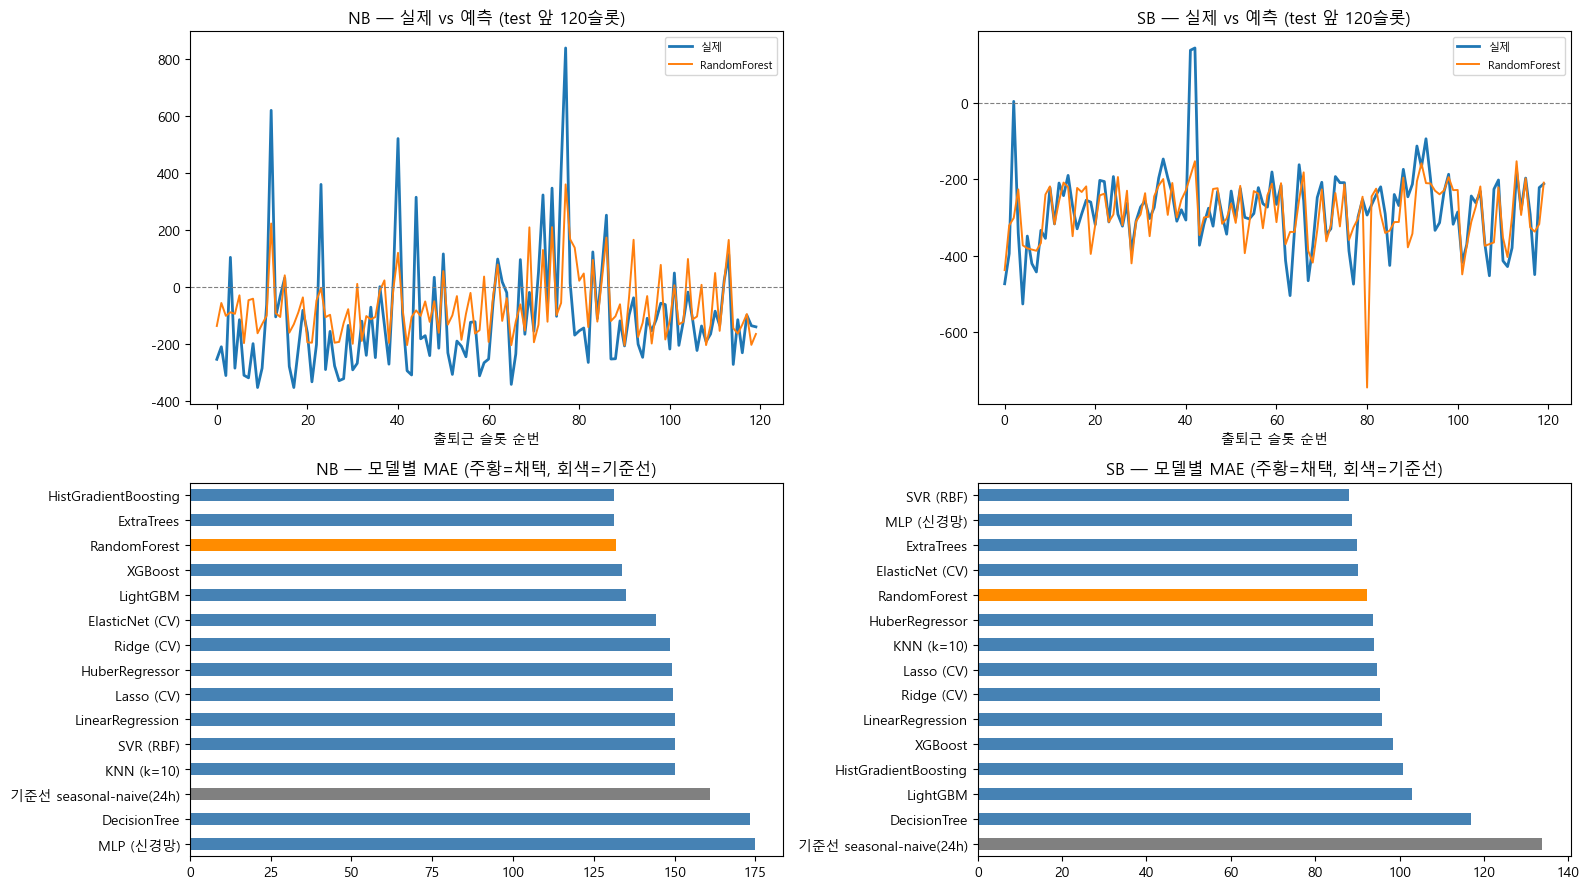

In [12]:
fig,axes=plt.subplots(2,2,figsize=(16,9))
for i,col in enumerate(["NB","SB"]):
    m,f,te,yt,p=FIT[(col,FINAL_MODEL)]
    s=yt.iloc[:120]
    axes[0,i].plot(range(len(s)),s.values,label="실제",lw=2)
    axes[0,i].plot(range(len(s)),p.iloc[:120].values,label=FINAL_MODEL,lw=1.4)
    axes[0,i].axhline(0,color="gray",ls="--",lw=.8)
    axes[0,i].set_title(f"{col} — 실제 vs 예측 (test 앞 120슬롯)")
    axes[0,i].legend(fontsize=8); axes[0,i].set_xlabel("출퇴근 슬롯 순번")
    sub=mres[mres.방향==col].sort_values("MAE").set_index("모델")["MAE"]
    colors=["darkorange" if n==FINAL_MODEL else ("gray" if n.startswith("기준선") else "steelblue")
            for n in sub.index]
    sub.plot(kind="barh",ax=axes[1,i],color=colors); axes[1,i].invert_yaxis()
    axes[1,i].set_title(f"{col} — 모델별 MAE (주황=채택, 회색=기준선)"); axes[1,i].set_ylabel("")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,"02_예측결과.png"),dpi=110,bbox_inches="tight")
plt.show()

In [13]:
sec("8. 요약")
print(f"[채택 전처리] {CHOICE}")
print(f"[채택 모델]   {FINAL_MODEL}")
print(f"[분할]        train ~2024-12-31 / test {TEST_START}~")
print()
print(final.round(3).to_string(index=False))
print("\n[기각한 전처리와 근거]")
print("  ② IQR 제거      — 평가표본 감소. MAE 개선은 어려운 표본 제외 효과")
print("  ④ 물리적 근거 제외 — 01번 품질필터가 이미 걸러 추가 효과 미미")
print("  ⑤ 평소값 차감    — 정보를 뺏는 방식. ⑦(피처 제공)이 우수")
print("  ⑥ 로그변환      — 부호가 바뀌는 변수에 부적합. 복원 시 오차 증폭")
print("\n[한계]")
print("  남행은 미금역 Av143 이 2025-03~05 에 소실되어 평가표본이 적다.")
print("  부트스트랩 신뢰구간(5절)으로 결론의 안정성을 함께 보고한다.")
print("\n생성 파일:",sorted(os.listdir(OUT_DIR)))
save_log(os.path.join(OUT_DIR,"02_모델링결과.txt"))


8. 요약
[채택 전처리] ⑧ 평소값 피처 + 윈저화
[채택 모델]   RandomForest
[분할]        train ~2024-12-31 / test 2025-01-01~

방향                      모델   n     MAE    RMSE     R2
NB 기준선 seasonal-naive(24h) 540 161.043 235.151  0.314
NB            RandomForest 540 131.864 181.078  0.593
SB 기준선 seasonal-naive(24h) 261 133.847 193.673 -0.213
SB            RandomForest 261  92.150 134.920  0.411

[기각한 전처리와 근거]
  ② IQR 제거      — 평가표본 감소. MAE 개선은 어려운 표본 제외 효과
  ④ 물리적 근거 제외 — 01번 품질필터가 이미 걸러 추가 효과 미미
  ⑤ 평소값 차감    — 정보를 뺏는 방식. ⑦(피처 제공)이 우수
  ⑥ 로그변환      — 부호가 바뀌는 변수에 부적합. 복원 시 오차 증폭

[한계]
  남행은 미금역 Av143 이 2025-03~05 에 소실되어 평가표본이 적다.
  부트스트랩 신뢰구간(5절)으로 결론의 안정성을 함께 보고한다.

생성 파일: ['02_모델비교.csv', '02_모델성능.csv', '02_변수중요도_NB.csv', '02_변수중요도_SB.csv', '02_신뢰구간.csv', '02_예측결과.png', '02_전처리비교.csv', '02_평가범위영향.csv']
로그 저장: ../outputs/02_모델링\02_모델링결과.txt  (75줄)
